In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score, classification_report, precision_recall_curve, roc_curve)

x_train = pd.read_csv('../data/processed/x_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
x_test = pd.read_csv('../data/processed/x_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print('x_train shape: ', x_train.shape)
print('x_test shape: ', x_test.shape)
print('\ny_train distribution: \n', y_train.value_counts())
print('\ny_test distribution: \n', y_test.value_counts())

x_train shape:  (1972, 44)
x_test shape:  (294, 44)

y_train distribution: 
 Attrition
0    986
1    986
Name: count, dtype: int64

y_test distribution: 
 Attrition
0    247
1     47
Name: count, dtype: int64


In [2]:
def evaluate_model(model, x_test, y_test, threshold=0.5, model_name="Model"):
    """
    Evaluates a trained model on test data.
    threshold: the probability cutoff above which we predict class 1 (attrition)
    """
    proba = model.predict_proba(x_test)[:, 1]
    preds = (proba >= threshold).astype(int)

    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    roc_auc = roc_auc_score(y_test, proba)

    print(f"\n{'='*135}")
    print(f"  {model_name}  (threshold = {threshold})")
    print(f"{'='*135}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"\n{classification_report(y_test, preds)}")

    return {"Model": model_name, "Threshold": threshold, "Precision": precision, "Recall": recall, "F1": f1, "ROC_AUC": roc_auc}

def find_best_threshold(model, x_test, y_test, min_recall=0.65, model_name='Model'):
    """
    Scans thresholds from 0.05 to 0.95 and finds:
      (a) threshold that gives highest F1
      (b) threshold that hits Recall >= min_recall while maximising F1
    """
    proba = model.predict_proba(x_test)[:, 1]
    thresholds = np.arange(0.05, 0.95, 0.01)

    results = []

    for t in thresholds:
        preds = (proba >= t).astype(int)
        precision = precision_score(y_test, preds, zero_division=0)
        recall = recall_score(y_test, preds, zero_division=0)
        f1 = f1_score(y_test, preds, zero_division=0)
        results.append({'threshold': t, 'precision': precision, 'recall': recall, 'f1': f1})

    df = pd.DataFrame(results)

    # best f1 overall
    best_f1_row = df.loc[df['f1'].idxmax()]

    # best f1 with recall constraint
    recall_constrained = df[df['recall'] >= min_recall]
    if not recall_constrained.empty:
        best_recall_row = recall_constrained.loc[recall_constrained['f1'].idxmax()]
    else:
        best_recall_row = None

    print(f"\n── {model_name} Threshold Scan ──")
    print(f"Best F1 threshold    : {best_f1_row['threshold']:.2f} "
          f"→ Precision={best_f1_row['precision']:.3f}, "
          f"Recall={best_f1_row['recall']:.3f}, F1={best_f1_row['f1']:.3f}")

    if best_recall_row is not None:
        print(f"Recall≥{min_recall} threshold : {best_recall_row['threshold']:.2f} "
              f"→ Precision={best_recall_row['precision']:.3f}, "
              f"Recall={best_recall_row['recall']:.3f}, F1={best_recall_row['f1']:.3f}")
    else:
        print(f"No threshold achieved Recall >= {min_recall}")

    return df

In [3]:
from joblib import load
lr_model = load('../models/Logistic_Regression.pkl')
rf_model = load('../models/Random_Forest.pkl')
xgb_model = load('../models/XGBoost.pkl')
print('All models loaded successfully.')

All models loaded successfully.


In [4]:
# ── Section 1: Threshold Optimization ────────────────────────────────────────
# First, evaluate both models at the default threshold of 0.5 (our baseline reference)
lr_default_metrics = evaluate_model(lr_model, x_test, y_test, threshold=0.5, model_name="Logistic Regression")
xgb_default_metrics = evaluate_model(xgb_model, x_test, y_test, threshold=0.5, model_name="XGBoost")


  Logistic Regression  (threshold = 0.5)
  Precision : 0.4737
  Recall    : 0.3830
  F1 Score  : 0.4235
  ROC-AUC   : 0.7887

              precision    recall  f1-score   support

           0       0.89      0.92      0.90       247
           1       0.47      0.38      0.42        47

    accuracy                           0.83       294
   macro avg       0.68      0.65      0.66       294
weighted avg       0.82      0.83      0.83       294


  XGBoost  (threshold = 0.5)
  Precision : 0.6111
  Recall    : 0.2340
  F1 Score  : 0.3385
  ROC-AUC   : 0.7652

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.61      0.23      0.34        47

    accuracy                           0.85       294
   macro avg       0.74      0.60      0.63       294
weighted avg       0.83      0.85      0.83       294



In [5]:
# ── Threshold Scan: LR and XGBoost ───────────────────────────────────────────
lr_scan  = find_best_threshold(lr_model,  x_test, y_test, min_recall=0.65, model_name="Logistic Regression")
xgb_scan = find_best_threshold(xgb_model, x_test, y_test, min_recall=0.65, model_name="XGBoost")


── Logistic Regression Threshold Scan ──
Best F1 threshold    : 0.19 → Precision=0.336, Recall=0.766, F1=0.468
Recall≥0.65 threshold : 0.19 → Precision=0.336, Recall=0.766, F1=0.468

── XGBoost Threshold Scan ──
Best F1 threshold    : 0.14 → Precision=0.367, Recall=0.702, F1=0.482
Recall≥0.65 threshold : 0.14 → Precision=0.367, Recall=0.702, F1=0.482


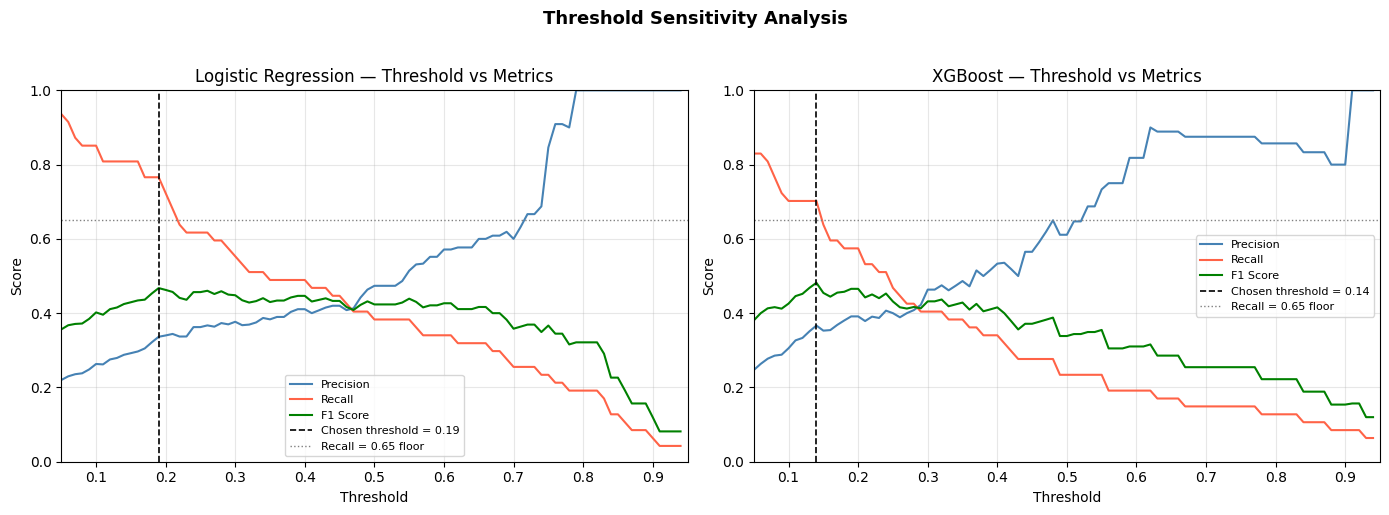

Plot saved.


In [6]:
# ── Plot Threshold Scan Curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scan_df, name, best_t in zip(
    axes,
    [lr_scan, xgb_scan],
    ["Logistic Regression", "XGBoost"],
    [0.19, 0.14]
):
    ax.plot(scan_df['threshold'], scan_df['precision'], label='Precision', color='steelblue')
    ax.plot(scan_df['threshold'], scan_df['recall'],    label='Recall',    color='tomato')
    ax.plot(scan_df['threshold'], scan_df['f1'],        label='F1 Score',  color='green')

    # Mark the chosen threshold
    ax.axvline(x=best_t, color='black', linestyle='--', linewidth=1.2, label=f'Chosen threshold = {best_t}')
    ax.axhline(y=0.65,   color='gray',  linestyle=':',  linewidth=1.0, label='Recall = 0.65 floor')

    ax.set_title(f'{name} — Threshold vs Metrics')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.set_xlim(0.05, 0.95)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.suptitle('Threshold Sensitivity Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/threshold_scan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [7]:
# ── Lock in Optimal Thresholds ────────────────────────────────────────────────
LR_THRESHOLD  = 0.19
XGB_THRESHOLD = 0.14

print(f"Logistic Regression optimal threshold : {LR_THRESHOLD}")
print(f"XGBoost optimal threshold             : {XGB_THRESHOLD}")

# ── Evaluate at Optimal Thresholds ───────────────────────────────────────────
lr_tuned  = evaluate_model(lr_model,  x_test, y_test, threshold=LR_THRESHOLD,  model_name="Logistic Regression (tuned threshold)")
xgb_tuned = evaluate_model(xgb_model, x_test, y_test, threshold=XGB_THRESHOLD, model_name="XGBoost (tuned threshold)")

Logistic Regression optimal threshold : 0.19
XGBoost optimal threshold             : 0.14

  Logistic Regression (tuned threshold)  (threshold = 0.19)
  Precision : 0.3364
  Recall    : 0.7660
  F1 Score  : 0.4675
  ROC-AUC   : 0.7887

              precision    recall  f1-score   support

           0       0.94      0.71      0.81       247
           1       0.34      0.77      0.47        47

    accuracy                           0.72       294
   macro avg       0.64      0.74      0.64       294
weighted avg       0.84      0.72      0.76       294


  XGBoost (tuned threshold)  (threshold = 0.14)
  Precision : 0.3667
  Recall    : 0.7021
  F1 Score  : 0.4818
  ROC-AUC   : 0.7652

              precision    recall  f1-score   support

           0       0.93      0.77      0.84       247
           1       0.37      0.70      0.48        47

    accuracy                           0.76       294
   macro avg       0.65      0.74      0.66       294
weighted avg       0.84      0.

In [8]:
# ── Section 2: Fix & Retune Random Forest ────────────────────────────────────

# Define the hyperparameter grid
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 2, 4]
}

# Base Model (with no class_weight)
rf_base = RandomForestClassifier(random_state=42)

# Stratified K-Fold with 5 folds having balanced class ratio in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search CV setup
rf_grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(x_train, y_train)

print(f'Best Parameters found: {rf_grid_search.best_params_}')
print(f'Best F1 score from Grid Search: {rf_grid_search.best_score_:.4f}')


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
Best F1 score from Grid Search: 0.9368


In [9]:
# ── Extract Best RF Model & Evaluate at Default Threshold ────────────────────
rf_tuned = rf_grid_search.best_estimator_
rf_tuned_default = evaluate_model(rf_tuned, x_test, y_test, threshold=0.5, model_name='RF Tuned (default threshold)')


  RF Tuned (default threshold)  (threshold = 0.5)
  Precision : 0.4444
  Recall    : 0.1702
  F1 Score  : 0.2462
  ROC-AUC   : 0.7278

              precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.44      0.17      0.25        47

    accuracy                           0.83       294
   macro avg       0.65      0.56      0.58       294
weighted avg       0.79      0.83      0.80       294



In [10]:
# ── Refined RF Grid: Constrained to Prevent Overfitting ──────────────────────
rf_param_grid_v2 = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 10],
    'min_samples_leaf': [2, 4, 8]
}

rf_base_v2 = RandomForestClassifier(random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid_search_v2 = GridSearchCV(
    estimator  = rf_base_v2,
    param_grid = rf_param_grid_v2,
    cv         = cv,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1
)

rf_grid_search_v2.fit(x_train, y_train)

print("\nBest parameters found:", rf_grid_search_v2.best_params_)
print("Best cross-val F1 score:", round(rf_grid_search_v2.best_score_, 4))

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best parameters found: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 300}
Best cross-val F1 score: 0.9273


In [11]:
# ── Extract Best RF Model v2 & Evaluate ──────────────────────────────────────
rf_tuned_v2 = rf_grid_search_v2.best_estimator_

rf_v2_default = evaluate_model(rf_tuned_v2, x_test, y_test, threshold=0.5, model_name="RF Tuned v2 (threshold=0.5)")


  RF Tuned v2 (threshold=0.5)  (threshold = 0.5)
  Precision : 0.4000
  Recall    : 0.1702
  F1 Score  : 0.2388
  ROC-AUC   : 0.7306

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       247
           1       0.40      0.17      0.24        47

    accuracy                           0.83       294
   macro avg       0.63      0.56      0.57       294
weighted avg       0.78      0.83      0.80       294



In [12]:
# ── RF Grid v3: Optimise for Recall Directly ─────────────────────────────────
rf_param_grid_v3 = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 10],
    'min_samples_leaf': [2, 4, 8]
}

rf_base_v3 = RandomForestClassifier(random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid_search_v3 = GridSearchCV(
    estimator  = rf_base_v3,
    param_grid = rf_param_grid_v3,
    cv         = cv,
    scoring    = 'recall',    # ← changed from 'f1' to 'recall'
    n_jobs     = -1,
    verbose    = 1
)

rf_grid_search_v3.fit(x_train, y_train)

print("\nBest parameters found:", rf_grid_search_v3.best_params_)
print("Best cross-val Recall score:", round(rf_grid_search_v3.best_score_, 4))

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best parameters found: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 300}
Best cross-val Recall score: 0.9016


In [13]:
# ── Extract Best RF Model v3 & Evaluate ──────────────────────────────────────
rf_tuned_v3 = rf_grid_search_v3.best_estimator_

rf_v3_default = evaluate_model(rf_tuned_v3, x_test, y_test, threshold=0.5, model_name="RF Tuned v3 (threshold=0.5)")


  RF Tuned v3 (threshold=0.5)  (threshold = 0.5)
  Precision : 0.4000
  Recall    : 0.1702
  F1 Score  : 0.2388
  ROC-AUC   : 0.7306

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       247
           1       0.40      0.17      0.24        47

    accuracy                           0.83       294
   macro avg       0.63      0.56      0.57       294
weighted avg       0.78      0.83      0.80       294



In [14]:
# ── Threshold Scan on RF Tuned v3 ────────────────────────────────────────────
rf_v3_scan = find_best_threshold(rf_tuned_v3, x_test, y_test, min_recall=0.65, model_name='RF Tuned v3')


── RF Tuned v3 Threshold Scan ──
Best F1 threshold    : 0.29 → Precision=0.323, Recall=0.660, F1=0.434
Recall≥0.65 threshold : 0.29 → Precision=0.323, Recall=0.660, F1=0.434


## Random Forest — Diagnosis & Conclusion

Random Forest was retrained without class_weight='balanced' (fixing the double-balancing problem from notebook 03). Three GridSearchCV runs were
performed with varying grids and scoring metrics (f1, recall).

In all cases, cross-validation scores were artificially high (~0.90+) because CV folds came from SMOTE-balanced training data (50/50), while
the test set reflects the real distribution (16% attrition). Random Forest's vote-proportion probability mechanism does not transfer well
across this distribution gap.

After threshold tuning, RF achieves Recall=0.66, F1=0.434, ROC-AUC=0.731 — the weakest result across all three models. RF will be included in the
final shootout for completeness but is not the recommended model.

In [15]:
# ── Section 3: Tune XGBoost ───────────────────────────────────────────────────
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [1, 2, 3] #For our training data that's 986/986 = 1 since SMOTE balanced it, but we can still experiment with values above 1 to push recall higher.
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(x_train, y_train)

print("\nBest parameters found:", xgb_grid_search.best_params_)
print("Best cross-val Recall score:", round(xgb_grid_search.best_score_, 4))

Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Best parameters found: {'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'scale_pos_weight': 3}
Best cross-val Recall score: 0.9888


In [16]:
# ── Extract Best XGBoost Model & Evaluate at Default Threshold ───────────────
xgb_tuned = xgb_grid_search.best_estimator_
xgb_tuned_default = evaluate_model(xgb_tuned, x_test, y_test, threshold=0.5, model_name='XGBoost Tuned (default threshold)')


  XGBoost Tuned (default threshold)  (threshold = 0.5)
  Precision : 0.1878
  Recall    : 0.8511
  F1 Score  : 0.3077
  ROC-AUC   : 0.6805

              precision    recall  f1-score   support

           0       0.91      0.30      0.45       247
           1       0.19      0.85      0.31        47

    accuracy                           0.39       294
   macro avg       0.55      0.58      0.38       294
weighted avg       0.80      0.39      0.43       294



In [17]:
# ── XGBoost Grid v2: Remove scale_pos_weight inflation ───────────────────────
xgb_param_grid_v2 = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [1]        # fixed at 1 — SMOTE already balanced
}

xgb_base_v2 = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_grid_search_v2 = GridSearchCV(
    estimator  = xgb_base_v2,
    param_grid = xgb_param_grid_v2,
    cv         = cv,
    scoring    = 'recall',
    n_jobs     = -1,
    verbose    = 1
)

xgb_grid_search_v2.fit(x_train, y_train)

print("\nBest parameters found:", xgb_grid_search_v2.best_params_)
print("Best cross-val Recall:", round(xgb_grid_search_v2.best_score_, 4))

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters found: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 200, 'scale_pos_weight': 1}
Best cross-val Recall: 0.9077


In [18]:
# ── Extract Best XGBoost v2 & Evaluate ───────────────────────────────────────
xgb_tuned_v2 = xgb_grid_search_v2.best_estimator_

xgb_v2_default = evaluate_model(xgb_tuned_v2, x_test, y_test, threshold=0.5, model_name="XGBoost Tuned v2 (threshold=0.5)")


  XGBoost Tuned v2 (threshold=0.5)  (threshold = 0.5)
  Precision : 0.6250
  Recall    : 0.3191
  F1 Score  : 0.4225
  ROC-AUC   : 0.7902

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.32      0.42        47

    accuracy                           0.86       294
   macro avg       0.75      0.64      0.67       294
weighted avg       0.84      0.86      0.84       294



In [19]:
# ── Threshold Scan on XGBoost Tuned v2 ───────────────────────────────────────
xgb_v2_scan = find_best_threshold(xgb_tuned_v2, x_test, y_test, min_recall=0.65, model_name="XGBoost Tuned v2")


── XGBoost Tuned v2 Threshold Scan ──
Best F1 threshold    : 0.08 → Precision=0.343, Recall=0.766, F1=0.474
Recall≥0.65 threshold : 0.08 → Precision=0.343, Recall=0.766, F1=0.474


In [20]:
# ── Lock in XGBoost Tuned v2 Threshold ───────────────────────────────────────
XGB_TUNED_THRESHOLD = 0.08
xgb_v2_tuned = evaluate_model(xgb_tuned_v2, x_test, y_test, threshold=XGB_TUNED_THRESHOLD, model_name='XGBoost Tuned v2 (threshold = 0.08)')


  XGBoost Tuned v2 (threshold = 0.08)  (threshold = 0.08)
  Precision : 0.3429
  Recall    : 0.7660
  F1 Score  : 0.4737
  ROC-AUC   : 0.7902

              precision    recall  f1-score   support

           0       0.94      0.72      0.82       247
           1       0.34      0.77      0.47        47

    accuracy                           0.73       294
   macro avg       0.64      0.74      0.65       294
weighted avg       0.85      0.73      0.76       294



In [21]:
# ── Section 4: Final Shootout ─────────────────────────────────────────────────

# Collect all final results into a comparison table
results = []

results.append(evaluate_model(lr_model, x_test, y_test, threshold=0.19, model_name='Logistic Regression'))
results.append(evaluate_model(rf_tuned_v3, x_test, y_test, threshold=0.29, model_name='Random Forest'))
results.append(evaluate_model(xgb_tuned_v2, x_test, y_test, threshold=0.08, model_name='XGBoost Tuned v2'))

# Comparison DataFrame

shootout_df = pd.DataFrame(results)[['Model', 'Threshold', 'Precision', 'Recall', 'F1', 'ROC_AUC']]
shootout_df = shootout_df.sort_values('Recall', ascending=False).reset_index(drop=True)

print('\n── Final Shootout Results ──')
print(shootout_df.to_string(index=False))


  Logistic Regression  (threshold = 0.19)
  Precision : 0.3364
  Recall    : 0.7660
  F1 Score  : 0.4675
  ROC-AUC   : 0.7887

              precision    recall  f1-score   support

           0       0.94      0.71      0.81       247
           1       0.34      0.77      0.47        47

    accuracy                           0.72       294
   macro avg       0.64      0.74      0.64       294
weighted avg       0.84      0.72      0.76       294


  Random Forest  (threshold = 0.29)
  Precision : 0.3229
  Recall    : 0.6596
  F1 Score  : 0.4336
  ROC-AUC   : 0.7306

              precision    recall  f1-score   support

           0       0.92      0.74      0.82       247
           1       0.32      0.66      0.43        47

    accuracy                           0.72       294
   macro avg       0.62      0.70      0.63       294
weighted avg       0.82      0.72      0.76       294


  XGBoost Tuned v2  (threshold = 0.08)
  Precision : 0.3429
  Recall    : 0.7660
  F1 Score  : 

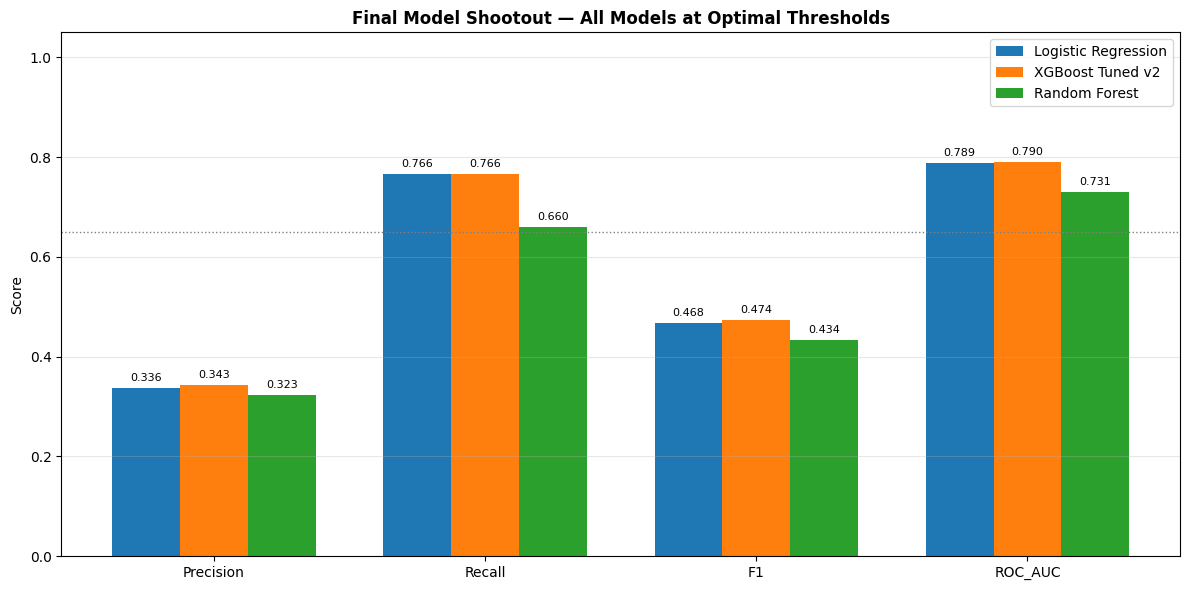

Plot saved.


In [22]:
# ── Final Shootout Bar Chart ──────────────────────────────────────────────────
metrics = ['Precision', 'Recall', 'F1', 'ROC_AUC']
models  = shootout_df['Model'].tolist()
x       = np.arange(len(metrics))
width   = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, (_, row) in enumerate(shootout_df.iterrows()):
    bars = ax.bar(x + i * width,
                  [row['Precision'], row['Recall'], row['F1'], row['ROC_AUC']],
                  width, label=row['Model'])
    # Add value labels on top of each bar
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Final Model Shootout — All Models at Optimal Thresholds', fontweight='bold')
ax.legend()
ax.axhline(y=0.65, color='gray', linestyle=':', linewidth=1.0, label='Recall floor = 0.65')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/final_shootout.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## Final Conclusion

**Recommended model: XGBoost Tuned v2 at threshold 0.08**

Hyperparameters: 
learning_rate=0.1, 
max_depth=5,
min_child_weight=5, 
n_estimators=200, 
scale_pos_weight=1

Performance on held-out test set:
- Recall:    0.766  (catches 36 of 47 actual leavers)
- Precision: 0.343  (1 in 3 flagged employees actually leaves)
- F1:        0.474
- ROC-AUC:   0.790

Business interpretation: 
Of 47 employees who actually left, this model correctly identifies 36 before they leave. The cost of the 11 missed leavers (false negatives) is judged
higher than the cost of investigating false alarms, which aligns with the business framing established at project start.

Logistic Regression at threshold 0.19 is a strong alternative; identical recall, marginally lower F1 and ROC-AUC. It would be preferred in contexts where model interpretability matters more than marginal performance gains.

Random Forest underperformed across all metrics and is not recommended for this problem.

In [23]:
# ── Save Final Winning Model ──────────────────────────────────────────────────
import joblib

joblib.dump(xgb_tuned_v2, '../outputs/models/xgboost_tuned_final.pkl')
print("Winning model saved: xgboost_tuned_final.pkl")
print(f"Model: XGBoost Tuned v2")
print(f"Threshold: {XGB_TUNED_THRESHOLD}")
print(f"Recall: 0.766 | F1: 0.474 | ROC-AUC: 0.790")

Winning model saved: xgboost_tuned_final.pkl
Model: XGBoost Tuned v2
Threshold: 0.08
Recall: 0.766 | F1: 0.474 | ROC-AUC: 0.790
